# CART Analysis — Human ITL — Plots

Loads the CSV outputs produced by `cart_analysis humanitl.ipynb` (counts, distances, colocalisation) from one or more analysis runs, derives per-image experimental conditions from filename tokens, and renders the publication figures.

**Inputs expected** (one folder per analysis run, each containing the three CSVs Step 3 writes):
- `all_counts_inc_percentage.csv`
- `all_distances_inc_percentage.csv`
- `all_colocalisation_inc_percentage.csv`

In [1]:
import pathlib
import warnings
import colorsys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import to_hex
from PIL import ImageColor
from scipy.stats import gaussian_kde

warnings.filterwarnings("ignore")

## Configuration

List the analysis-output folders to load. Each folder should contain the three CSVs from Step 3 of the segmentation notebook. Figures are written to `OUTPUT_DIR`.

In [9]:
ANALYSIS_DIRS = [
    pathlib.Path(r"z:\Marina\Stellaris\2026.03.10_CART\For analysis\best_labels\output_figures"),
    pathlib.Path(r"z:\Marina\Stellaris\2026.04.01_CART_setup\best_labels\output_figures"),
]
OUTPUT_DIR = pathlib.Path.cwd() / "plots"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Loading from {len(ANALYSIS_DIRS)} folder(s); writing figures to {OUTPUT_DIR}")

Loading from 2 folder(s); writing figures to c:\Users\taylorhearn\git_repos\image_quantification\CART_Analysis\plots


## Experimental-condition helper

`add_condition_label` derives `patient`, `day`, `flow`, `fixation`, `experiment`, and `condition` from substrings in the `image` and `lif_file` columns. Unrecognised values become `NaN`.


In [10]:
def add_condition_label(dataframe):
    """Add patient/day/flow/fixation/experiment/condition columns from filename substrings."""
    dataframe = dataframe.copy()

    def label(row):
        name = (str(row["image"]) + "|" + str(row["lif_file"])).lower()

        if   "fl32" in name: patient = "fl32"
        elif "fl12" in name: patient = "fl12"
        else:                patient = np.nan

        if   "day10" in name: day = "10"
        elif "day6"  in name: day = "6"
        elif "day7"  in name: day = "7"
        elif "day8"  in name: day = "8"
        elif "day9"  in name: day = "9"
        else:                 day = np.nan

        if   "3mm" in name: flow = "3mm"
        elif "7mm" in name: flow = "7mm"
        else:               flow = np.nan

        if   "fix"  in name: fixation = "fixed"
        elif "live" in name: fixation = "live"
        else:                fixation = np.nan

        if   "ari" in name: experiment = "ARi"
        elif "utd" in name: experiment = "UTD"
        else:               experiment = np.nan

        if day and flow and experiment and not any(pd.isna(v) for v in (day, flow, experiment)):
            condition = f"Day{day} {flow} {experiment}"
        else:
            condition = np.nan

        return pd.Series([patient, day, flow, fixation, experiment, condition],
                         index=["patient", "day", "flow", "fixation", "experiment", "condition"])

    dataframe[["patient", "day", "flow", "fixation", "experiment", "condition"]] = \
        dataframe.apply(label, axis=1)
    return dataframe


In [ ]:

cart_distances = add_condition_label(pd.read_csv(r"z:\Bel\Marina_Side_Projects\CART analysis\FINALS\Outputs\all_distances.csv"))
cart_colocalisation = add_condition_label(pd.read_csv(r"z:\Bel\Marina_Side_Projects\CART analysis\FINALS\Outputs\all_colocalisation.csv"))
cart_counts = add_condition_label(pd.read_csv(r"z:\Bel\Marina_Side_Projects\CART analysis\FINALS\Outputs\all_counts.csv"))

## CART scatter / bar / enrichment plots

Counts-based figures: per-condition CART metrics across regions, fixed-vs-live bars, and tumour/vasculature enrichment relative to the whole chip.

In [ ]:
# ── Shared CART-plot setup (reused by the bar cell below) ────────────────────
CART_PLOT_REGIONS = ["chip", "tumour", "chip_vasculature"]
CART_METRICS = [
    ("cell_count",         "CART Cell Count"),
    ("positive_pixels",    "CART Positive Pixels"),
    ("positive_pixel_pct", "CART Coverage (% of region)"),
]
FIXATION_CATEGORIES = ["fixed", "live"]

cart_data = all_results[
    (all_results["cell_type"] == "CART cells") &
    (all_results["region"].isin(CART_PLOT_REGIONS)) &
    (all_results["condition"].notna())
]
condition_order = list(dict.fromkeys(cart_data["condition"]))

# ── Scatter: CART cells per fixation, coloured by condition ──────────────────
condition_colors = {cond: plt.cm.tab20(i / max(len(condition_order) - 1, 1))
                    for i, cond in enumerate(condition_order)}

for metric, ylabel in CART_METRICS:
    fig, axes = plt.subplots(1, len(CART_PLOT_REGIONS), figsize=(12, 4),
                             sharey=False, constrained_layout=True)
    fig.suptitle(ylabel, fontsize=12, fontweight="bold")

    for ax, region in zip(axes, CART_PLOT_REGIONS):
        region_data = cart_data[cart_data["region"] == region]
        for fixation_index, fixation in enumerate(FIXATION_CATEGORIES):
            fixation_data = region_data[region_data["fixation"] == fixation]
            for condition in condition_order:
                values = fixation_data.loc[fixation_data["condition"] == condition, metric].values
                jitter = np.linspace(-0.15, 0.15, max(len(values), 1))
                for jitter_offset, value in zip(jitter, values):
                    ax.scatter(fixation_index + jitter_offset, value,
                               color=condition_colors[condition], s=30, alpha=0.5,
                               edgecolor="None", linewidth=0.4, zorder=3)
        ax.set_xticks(range(len(FIXATION_CATEGORIES)))
        ax.set_xticklabels(FIXATION_CATEGORIES, fontsize=10)
        ax.set_title(region.replace("_", " ").title(), fontsize=10)
        ax.set_ylabel(ylabel if ax is axes[0] else "")

    legend_handles = [
        Line2D([0], [0], marker="o", color="w",
               markerfacecolor=condition_colors[c], markersize=8, label=c)
        for c in condition_order
    ]
    fig.legend(handles=legend_handles, loc="outside right upper", fontsize=7, ncol=1)
    fig.savefig(OUTPUT_DIR / f"CART_{metric}_by_condition.png", dpi=150, bbox_inches="tight")
    plt.show()

In [ ]:
# ── Bar: Fixed vs Live per condition (reuses cart_data / condition_order) ───
bar_width = 0.35
fixation_colors = {"fixed": "#4C72B0", "live": "#DD8452"}

for metric, ylabel in CART_METRICS:
    fig, axes = plt.subplots(1, len(CART_PLOT_REGIONS), figsize=(14, 5),
                             sharey=False, constrained_layout=True)
    fig.suptitle(f"{ylabel} — Fixed vs Live", fontsize=12, fontweight="bold")

    for ax, region in zip(axes, CART_PLOT_REGIONS):
        region_data = cart_data[cart_data["region"] == region]
        grouped = region_data.groupby(["condition", "fixation"])[metric]
        means = grouped.mean().unstack(fill_value=0)
        sems = grouped.sem().unstack(fill_value=0)
        for fix in FIXATION_CATEGORIES:
            if fix not in means.columns:
                means[fix] = 0.0
                sems[fix] = 0.0
        means = means.reindex([c for c in condition_order if c in means.index])
        sems = sems.reindex(means.index)

        x = np.arange(len(means))
        ax.bar(x - bar_width / 2, means["fixed"], bar_width,
               yerr=sems["fixed"], capsize=3, color=fixation_colors["fixed"],
               edgecolor="white", label="Fixed")
        ax.bar(x + bar_width / 2, means["live"], bar_width,
               yerr=sems["live"], capsize=3, color=fixation_colors["live"],
               edgecolor="white", label="Live")
        ax.set_xticks(x)
        ax.set_xticklabels(means.index, fontsize=7, rotation=45, ha="right")
        ax.set_title(region.replace("_", " ").title(), fontsize=10)
        ax.set_ylabel(ylabel if ax is axes[0] else "")

    axes[-1].legend(fontsize=8)
    fig.savefig(OUTPUT_DIR / f"CART_{metric}_fixed_vs_live.png", dpi=150, bbox_inches="tight")
    plt.show()

In [ ]:
# ── Normalised CART enrichment per region ────────────────────────────────────
# Formula: (CART_px_in_region / CART_px_in_chip) * (region_area / chip_area)
enrichment_regions = ["tumour", "chip_vasculature", "chip_not_vasculature"]

cart_all = all_results[all_results["cell_type"] == "CART cells"].copy()
chip_rows = cart_all[cart_all["region"] == "chip"][
    ["image", "positive_pixels", "region_area_px"]
].rename(columns={"positive_pixels": "cart_px_chip", "region_area_px": "area_chip"})

enrichment = cart_all[cart_all["region"].isin(enrichment_regions)].merge(
    chip_rows, on="image", how="left")
enrichment["cart_enrichment"] = (
    (enrichment["positive_pixels"] / enrichment["cart_px_chip"].replace(0, np.nan)) *
    (enrichment["region_area_px"]  / enrichment["area_chip"].replace(0, np.nan))
)

fig, axes = plt.subplots(1, len(enrichment_regions), figsize=(14, 5),
                         sharey=False, constrained_layout=True)
fig.suptitle("CART Normalised Score\n(CART in region / CART in chip) * (region area / chip area)",
             fontsize=11, fontweight="bold")

for ax, region in zip(axes, enrichment_regions):
    region_data = enrichment[enrichment["region"] == region]
    conditions = list(dict.fromkeys(region_data["condition"].dropna()))
    x_positions = np.arange(len(conditions))
    means = [region_data.loc[region_data["condition"] == c, "cart_enrichment"].mean() for c in conditions]
    sems  = [region_data.loc[region_data["condition"] == c, "cart_enrichment"].sem()  for c in conditions]
    ax.bar(x_positions, means, yerr=sems, capsize=3, color="#5A9BD5", edgecolor="white")
    for xi, c in enumerate(conditions):
        vals = region_data.loc[region_data["condition"] == c, "cart_enrichment"].values
        jitter = np.linspace(-0.15, 0.15, max(len(vals), 1))
        for j, v in zip(jitter, vals):
            ax.scatter(xi + j, v, color="black", s=15, alpha=0.5, zorder=5)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(conditions, fontsize=7, rotation=45, ha="right")
    ax.set_title(region.replace("_", " ").title(), fontsize=10)
    ax.set_ylabel("Normalised CART score" if ax is axes[0] else "")

fig.savefig(OUTPUT_DIR / "CART_normalised_enrichment.png", dpi=150, bbox_inches="tight")
plt.show()

enrichment.to_csv(OUTPUT_DIR / "enrichment_quantities.csv", index=False)
print(f"Saved enrichment CSV \u2192 {OUTPUT_DIR / 'enrichment_quantities.csv'}")

## Distance-from-tumour KDE + B/CART colocalisation

Helpers and per-day plots.

In [27]:
def create_n_valued_palette(base_colour_hex, n=5):
    r, g, b = ImageColor.getcolor(base_colour_hex, "RGB")
    r, g, b = r / 255, g / 255, b / 255
    h, l, s = colorsys.rgb_to_hls(r, g, b)
    palette = []
    for a in np.linspace(0.5, 1.4, n):
        l_adj = min(max(l * a, 0), 1)
        palette.append(to_hex(colorsys.hls_to_rgb(h, l_adj, s)))
    return palette


DEFAULT_PALETTE = {
    "ARi": "#FF8C00",   # orange
    "UTD": "#000000",   # black
}


def _build_img_color(df, group_col="experiment", palette_map=None):
    """Per-image colours derived from group membership."""
    if palette_map is None:
        palette_map = DEFAULT_PALETTE
    img_color, group_images, group_base_colors = {}, {}, {}
    for group_name, base_hex in palette_map.items():
        grp_imgs = df.loc[df[group_col] == group_name, "image"].unique().tolist()
        if not grp_imgs:
            continue
        shades = create_n_valued_palette(base_hex, max(len(grp_imgs), 2))
        for k, img_name in enumerate(grp_imgs):
            img_color[img_name] = shades[k % len(shades)]
        group_images[group_name] = grp_imgs
        group_base_colors[group_name] = base_hex
    for img_name in df["image"].unique():
        img_color.setdefault(img_name, "gray")
    return img_color, group_images, group_base_colors


def plot_distance_kde(df, save_title, title_suffix="", group_col="experiment", palette_map=None, save_type="pdf"):
    """KDE of distance from tumour edge per cell type, colour-coded by group."""
    if df.empty:
        print(f"No data for{title_suffix} \u2014 skipping.")
        return
    img_color, group_images, group_base_colors = _build_img_color(df, group_col, palette_map)
    cell_types = df["cell_type"].unique()
    imgs = df["image"].unique()

    fig, axes = plt.subplots(1, len(cell_types), figsize=(7 * len(cell_types), 4),
                             sharey=False, constrained_layout=True)
    if len(cell_types) == 1:
        axes = [axes]

    x_grid = np.linspace(0, df["distance_from_tumour_um"].max(), 500)

    for ax, ct in zip(axes, cell_types):
        sub_ct = df[df["cell_type"] == ct]
        group_densities = {g: [] for g in group_base_colors}

        for img_name in imgs:
            vals = sub_ct[sub_ct["image"] == img_name]["distance_from_tumour_um"].values
            if len(vals) < 2:
                continue
            y = gaussian_kde(vals)(x_grid)
            ax.plot(x_grid, y, color=img_color.get(img_name, "gray"),
                    alpha=0.5, linewidth=1.2, label=img_name)
            for grp_name, grp_imgs in group_images.items():
                if img_name in grp_imgs:
                    group_densities[grp_name].append(y)
                    break

        for grp_name, densities in group_densities.items():
            if not densities:
                continue
            mean_y = np.mean(densities, axis=0)
            ax.plot(x_grid, mean_y, color=group_base_colors[grp_name],
                    linewidth=2.5, linestyle="--", label=f"Mean {grp_name}")
            if len(densities) > 1:
                sd_y = np.std(densities, axis=0)
                ax.fill_between(x_grid, mean_y - sd_y, mean_y + sd_y,
                                color=group_base_colors[grp_name], alpha=0.15,
                                label=f"\u00b11 SD {grp_name}")

        ax.set_title(ct, fontsize=11, fontweight="bold")
        ax.set_xlabel("Distance from tumour edge (\u00b5m)", fontsize=9)
        ax.set_ylabel("Density", fontsize=9)
        ax.legend(fontsize=7, ncol=1)

    fig.suptitle(f"Distance from tumour edge{title_suffix}", fontsize=11, fontweight="bold")
    plt.savefig(f"{save_title}.{save_type}")
    plt.show()


COLOC_YLABELS = {
    "coarse_pearson": "Pearson r (blurred channels)",
    "B_near_CART":    "Fraction of B cells near a CART cell",
    "CART_near_B":    "Fraction of CART cells near a B cell",
}


def plot_colocalisation(df, save_title, title_suffix="", group_col="experiment", palette_map=None,
                        methods=("CART_near_B",), plot_regions=("chip",)):
    """Line plot of colocalisation score vs scale (\u00b5m), one row per method, one col per region."""
    if df.empty:
        print(f"No data for{title_suffix} \u2014 skipping.")
        return
    img_color, group_images, group_base_colors = _build_img_color(df, group_col, palette_map)
    images = df["image"].unique()
    n_rows, n_cols = len(methods), len(plot_regions)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows),
                             constrained_layout=True, squeeze=False)
    fig.suptitle(f"Colocalisation \u2014 B cells \u2194 CART cells{title_suffix}",
                 fontsize=11, fontweight="bold")

    for row, method in enumerate(methods):
        sub_m = df[df["method"] == method]
        for col, region in enumerate(plot_regions):
            ax = axes[row, col]
            sub = sub_m[sub_m["region"] == region].copy()

            for img_name in images:
                s = sub[sub["image"] == img_name].sort_values("param_um")
                ax.plot(s["param_um"], s["score"],
                        color=img_color.get(img_name, "gray"),
                        alpha=0.7, linewidth=1, linestyle="dashdot", label=img_name)

            for grp_name, base_color in group_base_colors.items():
                mean_grp = (sub[sub[group_col] == grp_name]
                            .groupby("param_um")["score"].mean().reset_index())
                std_grp = (sub[sub[group_col] == grp_name]
                           .groupby("param_um")["score"].std().reset_index()
                           .rename(columns={"score": "sd"}))
                if mean_grp.empty:
                    continue
                merged = mean_grp.merge(std_grp, on="param_um")
                ax.plot(merged["param_um"], merged["score"],
                        color=base_color, linewidth=2.5, linestyle="--",
                        label=f"Mean {grp_name}")
                if merged["sd"].notna().any():
                    ax.fill_between(merged["param_um"],
                                    merged["score"] - merged["sd"],
                                    merged["score"] + merged["sd"],
                                    color=base_color, alpha=0.15, label=f"\u00b11 SD {grp_name}")

            ax.set_ylim(-1, 1) if method == "coarse_pearson" else ax.set_ylim(0, 1)
            if method == "coarse_pearson":
                ax.axhline(0, color="gray", linewidth=0.7, linestyle=":")
            if row == 0:
                ax.set_title(region, fontsize=9, fontweight="bold")
            ax.set_xlabel("Scale (\u00b5m)", fontsize=8)
            ax.set_ylabel(COLOC_YLABELS.get(method, method) if col == 0 else "", fontsize=8)
            ax.tick_params(labelsize=7)

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles[:15], labels[:15], loc="outside right upper", fontsize=7, ncol=1)
    plt.savefig(OUTPUT_DIR / f"{save_title}.pdf")
    plt.show()

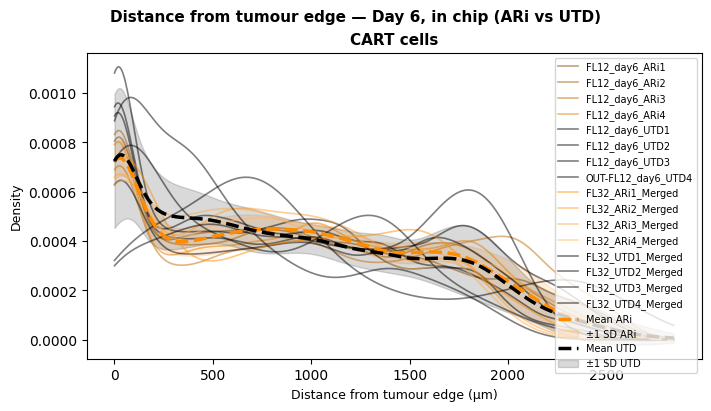

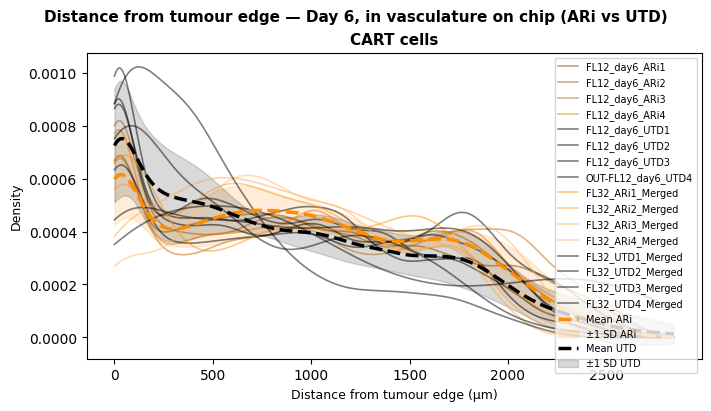

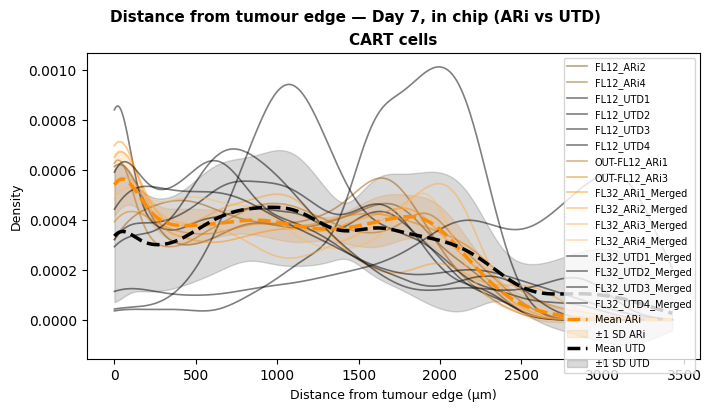

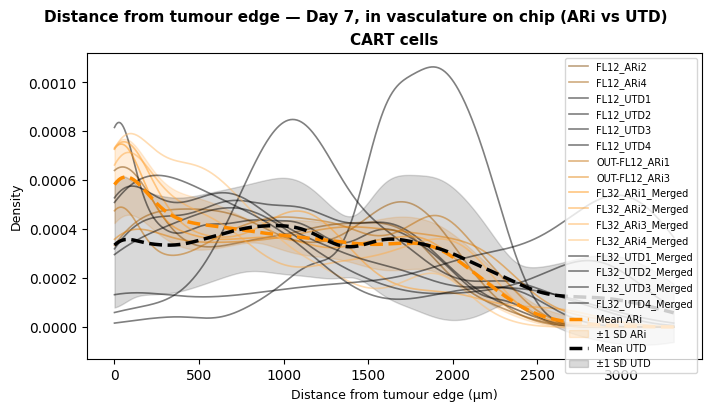

In [28]:
# ── CART distance KDE + B/CART colocalisation, per day ──────────────────────
COLOC_REGIONS = ["chip", "chip_vasculature", "chip_not_vasculature"]
DAYS_TO_PLOT = ("6", "7")

for day in DAYS_TO_PLOT:
    dist_day = cart_distances[
        (cart_distances["day"] == day) &
        (cart_distances["cell_type"] == "CART cells")
    ]

    plot_distance_kde(
        dist_day[dist_day["in_chip"] == True],
        save_title=f"CART_day{day}_CART_in_chip",
        title_suffix=f" \u2014 Day {day}, in chip (ARi vs UTD)",
        save_type="png"
    )

    plot_distance_kde(
        dist_day[(dist_day["in_chip"] == True) & (dist_day["in_chip_vasculature"] == True)],
        save_title=f"CART_day{day}_CART_in_chip_vasculature",
        title_suffix=f" \u2014 Day {day}, in vasculature on chip (ARi vs UTD)",
        save_type="png"
    )


In [22]:
cart_setup_distances.flow.unique()

array(['3mm', '7mm'], dtype=object)

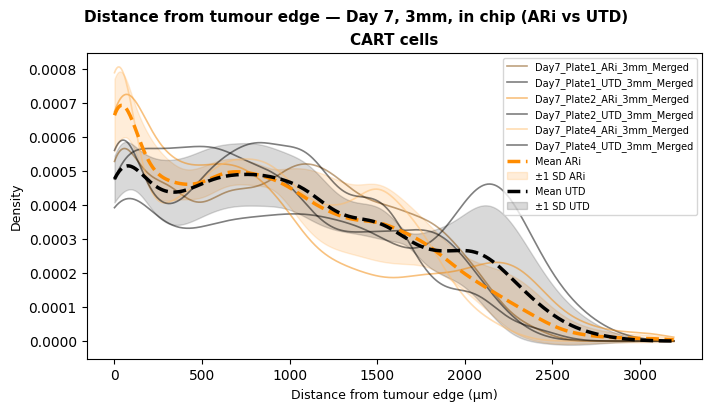

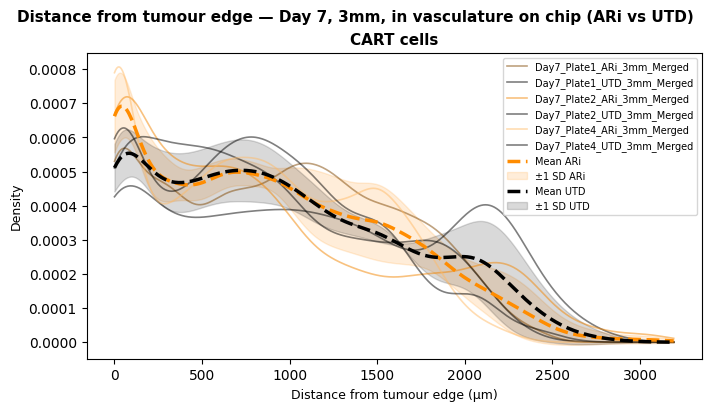

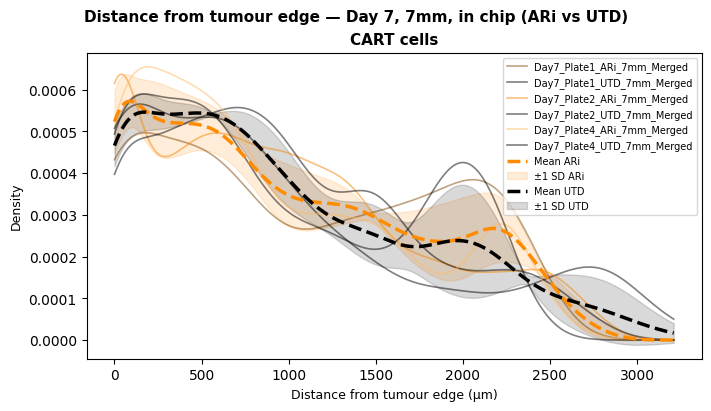

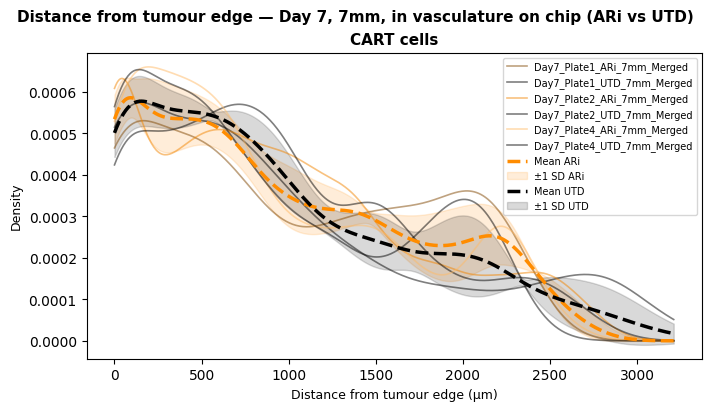

In [29]:
# ── CART distance KDE per day, split by flow (UTD vs ARi) ───────────────────
DAYS_TO_PLOT = ("7",)
FLOWS_TO_PLOT = ("3mm", "7mm")

for day in DAYS_TO_PLOT:
    dist_day = cart_setup_distances[
        (cart_setup_distances["day"] == day) &
        (cart_setup_distances["cell_type"] == "CART cells")
    ]

    for flow in FLOWS_TO_PLOT:
        dist_flow = dist_day[dist_day["flow"] == flow]

        plot_distance_kde(
            dist_flow[dist_flow["in_chip"] == True],
            save_title=f"CART_SETUP_day{day}_{flow}_CART_in_chip",
            title_suffix=f" \u2014 Day {day}, {flow}, in chip (ARi vs UTD)",
            save_type="png"
        )

        plot_distance_kde(
            dist_flow[(dist_flow["in_chip"] == True) & (dist_flow["in_chip_vasculature"] == True)],
            save_title=f"CART_SETUP_day{day}_{flow}_CART_in_chip_vasculature",
            title_suffix=f" \u2014 Day {day}, {flow}, in vasculature on chip (ARi vs UTD)",
            save_type="png"
        )


In [16]:
cart_setup_distances[cart_setup_distances["day"]==7]

,lif_file,patient,day,image,cell_type,distance_from_tumour_um,in_chip,in_not_chip,in_tumour,in_chip_not_tumour,in_chip_vasculature,in_chip_not_vasculature,in_left,in_right,flow,fixation,experiment,condition
